# A multilayer perceptron (MLP) for classification
***

We propose a simple model for assessing the impact of tephra fallout at a given location in La Palma based on deposit thickness data. 
We use the volcanic tephra deposition dataset from the 2021 Tajogaite Eruption on La Palma reported by [Shatto et al. (2024)][dataset].
The dataset comprises a total of 415 in-situ field measurements sampled across the Island of La Palma. These 66 surface change values were used to accurately complete the 66 values estimated from surface changes in areas not suitable for in-situ sampling. The dataset is available on [Zenodo][zenodo].

<img src="https://ars.els-cdn.com/content/image/1-s2.0-S2352340923009800-gr2.jpg" width="400">

[dataset]: https://doi.org/10.1016/j.dib.2023.109949
[zenodo]: https://doi.org/10.5281/zenodo.8338991

## Importing modules

In [1]:
import pandas as pd                                        # tools for data manipulation and analysis
import numpy as np                                         # numerical operations on arrays
import matplotlib.pyplot as plt                            # plots and visualizations

import torch                                               # main PyTorch library for tensor computation
import torch.nn as nn                                      # building blocks for creating and training neural networks
import torch.optim as optim                                # implementation of various optimization algorithms
from torch.utils.data import Dataset, DataLoader           # dataset utilities

from sklearn.model_selection import train_test_split       # utility to easily split datasets

## Loading dataset

In [2]:
df = pd.read_csv('data/palma-deposit.csv')
df

,lat,lon,thickness_cm
0,28.577990,-17.877680,15.000
1,28.592690,-17.879120,20.000
2,28.598040,-17.880200,28.000
3,28.604890,-17.879860,80.000
4,28.603480,-17.885430,80.000
...,...,...,...
476,28.617246,-17.861019,212.702
477,28.617835,-17.863486,317.431
478,28.617206,-17.863197,460.203
479,28.614424,-17.860961,223.153


## Defining multiple classes

We define three classes of tephra fallout impacts in terms of the deposit thickness:

|Impact    | Thickness range   | Label |
|----------|-------------------|-------|
| Low      | < 2 mm            | 0     |
| Moderate | 2 - 10 mm         | 1     |
| High     | > 10 mm           | 2     |

In [7]:
## Define the target as the class label

df['target'] = 0
df.loc[df['thickness_cm']>0.1,'target'] = 1
df.loc[df['thickness_cm']>4,'target']  = 2

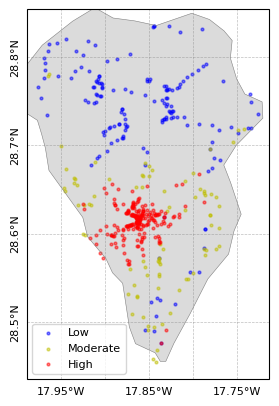

In [6]:
from helper_plot import create_map

fig, ax = create_map()

for target, label, color in [(0,'Low','b'), (1,'Moderate','y'), (2,'High','r')]:
    df.loc[df.target==target].plot.scatter(
        x='lon', y='lat', 
        c=color,
        s=4,
        alpha=0.5,
        label = label,
        ax = ax)

## Training a neural network and evaluating performance

In [10]:
def train_epoch(model, loader, criterion, optimizer):
    # Training mode
    model.train()
    
    total_loss = 0.0
    corrects   = 0
    
    for xb, yb in loader:
        logits = model(xb)
        loss = criterion(logits, yb)
        
        optimizer.zero_grad()        
        loss.backward()
        optimizer.step()
        
        predictions = torch.argmax(logits,dim=1)

        # Update metrics        
        total_loss += loss.item()
        corrects += (predictions == yb).sum().item()

    # Return average loss and accuracy (%)
    return total_loss / len(loader.dataset), 100 * corrects / len(loader.dataset)

In [16]:
def evaluate_epoch(model, loader, criterion):
    # Inference mode
    model.eval()
    
    total_loss = 0.0
    corrects = 0
    
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)

            predictions = torch.argmax(logits,dim=1)

            # Update metrics
            total_loss += loss.item()
            corrects += (predictions == yb).sum().item()

    # Return average loss and accuracy (%)
    return total_loss / len(loader.dataset), 100 * corrects / len(loader.dataset)

## Datasets

* Training dataset: Used to optimize the model parameters (learn weights)
* Validation dataset: Used during training to monitor performance (used for hyperparameter tuning, early stopping, etc...)
* Test dataset: Used once to evaluate the final chosen model for a fair (unbiased) reporting of model performance

In [4]:
# Define features and target
features = ['lat','lon']
X = df[features].values
y = df['target'].values

# Splitting arrays (80/20 %)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from helper import Standardize, ThicknessDataset

# Compute normalization stats from training data only
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)

# Define transform
transform = Standardize(mean,std)

# Datasets
dataset_train = ThicknessDataset(X_train, y_train, transform=transform)
dataset_val   = ThicknessDataset(X_val, y_val, transform=transform)

## Model: A simple multilayer perceptron classifier

In [57]:
# ---------------------------
# Simple MLP classifier
# ---------------------------
class Classifier(nn.Module):
    def __init__(self, in_dim=2, hidden=64, out_dim=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim)  # output logits
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)  # shape [B]

## Training loop

In [108]:
#
# Configuration
#
conf = {
    'BATCH_SIZE': 16,
    'LEARNING_RATE': 4E-4,
    'NUM_EPOCHS': 800,
}

# DataLoader
loader_train = DataLoader(dataset_train, batch_size=conf['BATCH_SIZE'], shuffle=True)
loader_val   = DataLoader(dataset_val,   batch_size=conf['BATCH_SIZE'], shuffle=False)

# Model
model = Classifier()

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=conf['LEARNING_RATE'])

In [102]:
train_losses = []
train_accs   = []
val_losses   = []
val_accs     = []

for epoch in range(conf['NUM_EPOCHS']):
    train_loss, train_acc = train_epoch(model, loader_train, criterion, optimizer)
    val_loss,   val_acc   = evaluate_epoch(model, loader_val, criterion)

    # Store current losses/accuracies
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Print log
    if epoch%10 == 0:
        print(f"Epoch {epoch+1:02d}:")
        print(f"Train loss (accuracy): {train_loss:.4f} ({train_acc:.2f}%) || Validation loss (accuracy): {val_loss:.4f} ({val_acc:.2f}%)")

Epoch 01:
Train loss (accuracy): 0.0618 (66.93%) || Validation loss (accuracy): 0.0604 (78.35%)
Epoch 11:
Train loss (accuracy): 0.0214 (86.98%) || Validation loss (accuracy): 0.0205 (87.63%)
Epoch 21:
Train loss (accuracy): 0.0182 (89.58%) || Validation loss (accuracy): 0.0173 (88.66%)
Epoch 31:
Train loss (accuracy): 0.0169 (90.36%) || Validation loss (accuracy): 0.0165 (88.66%)
Epoch 41:
Train loss (accuracy): 0.0166 (90.10%) || Validation loss (accuracy): 0.0172 (88.66%)
Epoch 51:
Train loss (accuracy): 0.0159 (90.10%) || Validation loss (accuracy): 0.0178 (88.66%)
Epoch 61:
Train loss (accuracy): 0.0156 (89.32%) || Validation loss (accuracy): 0.0187 (88.66%)
Epoch 71:
Train loss (accuracy): 0.0152 (90.10%) || Validation loss (accuracy): 0.0192 (88.66%)
Epoch 81:
Train loss (accuracy): 0.0149 (90.10%) || Validation loss (accuracy): 0.0194 (88.66%)
Epoch 91:
Train loss (accuracy): 0.0147 (90.10%) || Validation loss (accuracy): 0.0198 (88.66%)
Epoch 101:
Train loss (accuracy): 0.0143

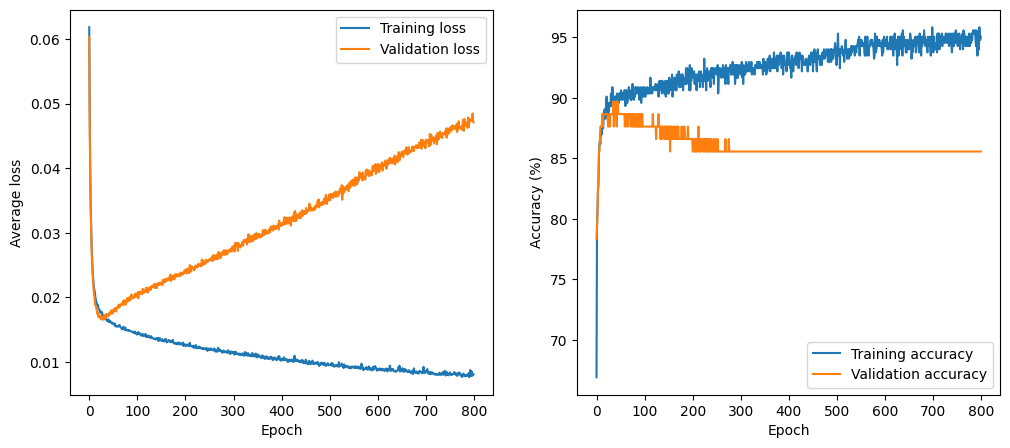

In [103]:
fig, axs = plt.subplots(ncols = 2, figsize=(12,5))

axs[0].plot(train_losses, label = 'Training loss')
axs[0].plot(val_losses,   label = 'Validation loss')

axs[1].plot(train_accs, label = "Training accuracy")
axs[1].plot(val_accs,   label = "Validation accuracy")

axs[0].set(ylabel = 'Average loss', xlabel = 'Epoch')
axs[1].set(ylabel = 'Accuracy (%)', xlabel = 'Epoch')

for ax in axs: ax.legend()

## Decision regions

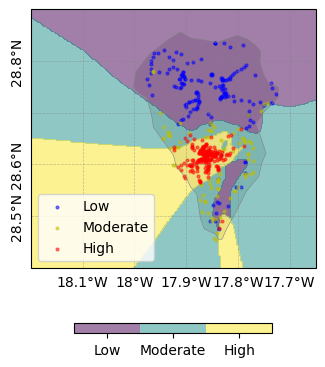

In [104]:
from helper_plot import plot_decision_regions

ax = plot_decision_regions(model, transform)

for target, label, color in [(0,'Low','b'), (1,'Moderate','y'), (2,'High','r')]:
    df.loc[df.target==target].plot.scatter(
        x='lon', y='lat', 
        c=color,
        s=4,
        alpha=0.5,
        label = label,
        ax = ax)